In [ ]:
!pip install -U seaborn
!pip install umap-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Purpose of Notebook

The purpose of this notebook is to try clustering with DBSCAN and on the Graph embeddings and see differences

# Loading Data with Cluster Labels

In [ ]:
from pathlib import Path
DATA_FOLDER = Path('/content/drive/MyDrive/DSCI599/data')
VIZ_FOLDER = Path('/content/drive/MyDrive/DSCI599/viz')

assert DATA_FOLDER.exists()
assert VIZ_FOLDER.exists()


In [ ]:
import pandas as pd
# currently using one
df = pd.read_csv(DATA_FOLDER / "df_cluster.csv")
df.head()

,int_source_ip,destination_port,protocol,num_scanned_destination_ips,num_unique_flows,num_packets,same_packet_size_flag,avg_packet_size,num_unique_Bs_scanned,num_unique_Cs_scanned,num_unique_Ds_scanned,num_scanned_24_blocks,num_non_conficker_destinations,time_activity,ip_scanned_rate,graph_labels,normal_labels
0,16968188,23,6,316.0,316.0,945.0,1.0,60.0,175.0,182.0,177.0,316.0,65.0,3540.0,0.089266,16,13
1,17372742,445,6,661.0,661.0,1322.0,1.0,48.0,125.0,234.0,126.0,654.0,661.0,3540.0,0.186723,15,-1
2,17384594,445,6,169.0,169.0,329.0,1.0,48.0,98.0,117.0,89.0,169.0,169.0,3360.0,0.050298,-1,-1
3,17400985,23,6,256.0,256.0,762.0,1.0,60.0,1.0,1.0,256.0,1.0,128.0,0.0,-1.000000,16,14
4,17401572,445,6,571.0,571.0,1142.0,1.0,48.0,124.0,232.0,125.0,564.0,571.0,3540.0,0.161299,15,-1


In [ ]:
df['graph_labels'] = pd.Categorical(df['graph_labels'])
df['normal_labels'] = pd.Categorical(df['normal_labels'])

In [ ]:
features = df.drop(columns=[
    "int_source_ip",
    "destination_port",
    "protocol",
    "graph_labels",
    "normal_labels"
])

features.head()

,num_scanned_destination_ips,num_unique_flows,num_packets,same_packet_size_flag,avg_packet_size,num_unique_Bs_scanned,num_unique_Cs_scanned,num_unique_Ds_scanned,num_scanned_24_blocks,num_non_conficker_destinations,time_activity,ip_scanned_rate
0,316.0,316.0,945.0,1.0,60.0,175.0,182.0,177.0,316.0,65.0,3540.0,0.089266
1,661.0,661.0,1322.0,1.0,48.0,125.0,234.0,126.0,654.0,661.0,3540.0,0.186723
2,169.0,169.0,329.0,1.0,48.0,98.0,117.0,89.0,169.0,169.0,3360.0,0.050298
3,256.0,256.0,762.0,1.0,60.0,1.0,1.0,256.0,1.0,128.0,0.0,-1.000000
4,571.0,571.0,1142.0,1.0,48.0,124.0,232.0,125.0,564.0,571.0,3540.0,0.161299


In [ ]:
import numpy as np
numeric_columns = features.select_dtypes(include=[np.number]).columns

In [ ]:
df['normal_labels'].value_counts()

,count
normal_labels,
-1,46571
13,42329
10,8370
21,6206
0,3578
1,3132
26,1869
14,1687
7,1671


In [ ]:
df['graph_labels'].value_counts()

,count
graph_labels,
16,80470
17,16825
-1,13600
15,11676
13,3233
14,2536
3,2128
12,642
7,501


# High-level Viz

In [ ]:
# import umap
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features)

# umap_map = umap.UMAP(n_components=2, random_state=42)
# umap_features = umap_map.fit_transform(features_scaled)

In [ ]:
# umap_df = pd.DataFrame(umap_features, columns = ['umap_1', 'umap_2'])
# umap_df.head()

In [ ]:
# umap_df.to_csv(DATA_FOLDER / "umap.csv")
umap_df = pd.read_csv(DATA_FOLDER / "umap.csv").drop(columns = "Unnamed: 0")

In [ ]:
umap_df['graph_labels'] = pd.Categorical(df['graph_labels'])
umap_df['normal_labels'] = pd.Categorical(df['normal_labels'])
umap_df.head()

,umap_1,umap_2,graph_labels,normal_labels
0,-0.951043,-0.123360,16,13
1,7.546940,5.778904,15,-1
2,-1.376558,-3.076848,-1,-1
3,17.221125,3.237194,16,14
4,8.040976,6.078938,15,-1


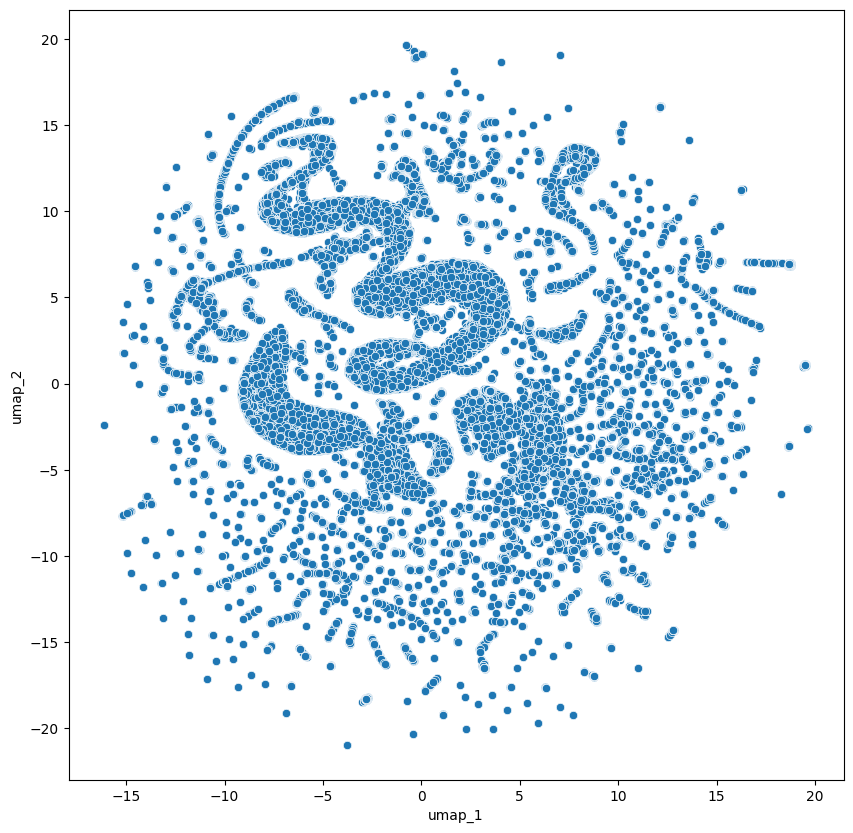

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10), dpi=100)

sns.scatterplot(umap_df, x= 'umap_1', y='umap_2')
plt.show()

In [ ]:
import seaborn as sns
sns.color_palette("tab10")
plt.figure(figsize=(10,10), dpi=100)

sns.scatterplot(umap_df, x= 'umap_1', y='umap_2', hue='normal_labels', alpha=0.2)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


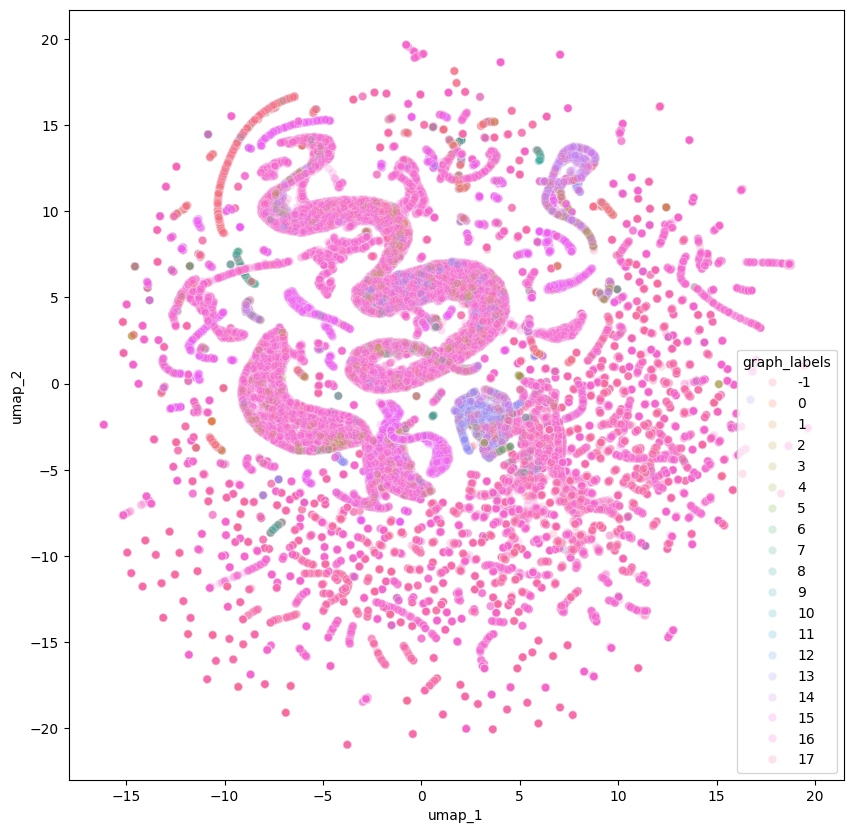

In [ ]:
import seaborn as sns
sns.color_palette("Paired")

plt.figure(figsize=(10,10), dpi=100)

sns.scatterplot(umap_df, x= 'umap_1', y='umap_2', hue='graph_labels', alpha=0.2)
plt.show()

# Normal Clusters

num_scanned_destination_ips


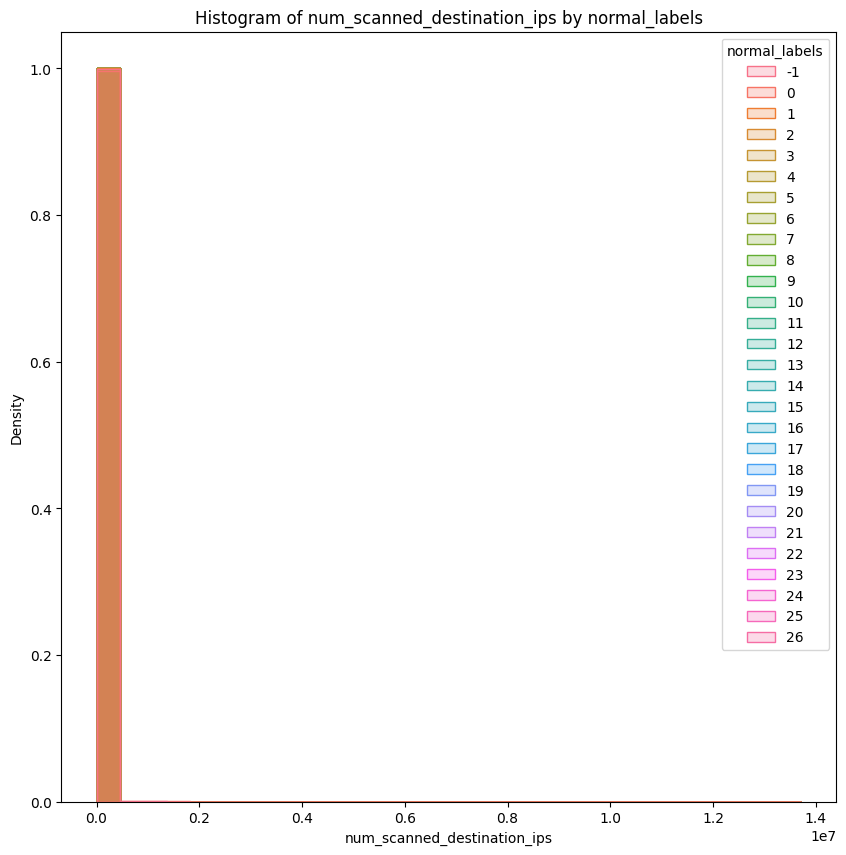

num_unique_flows


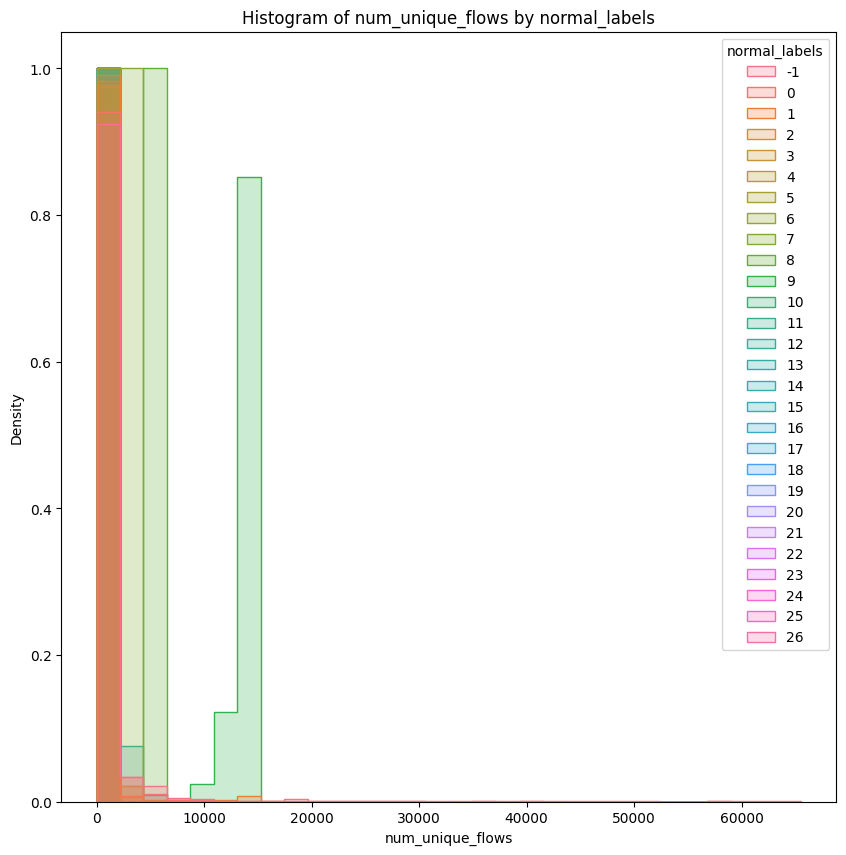

num_packets


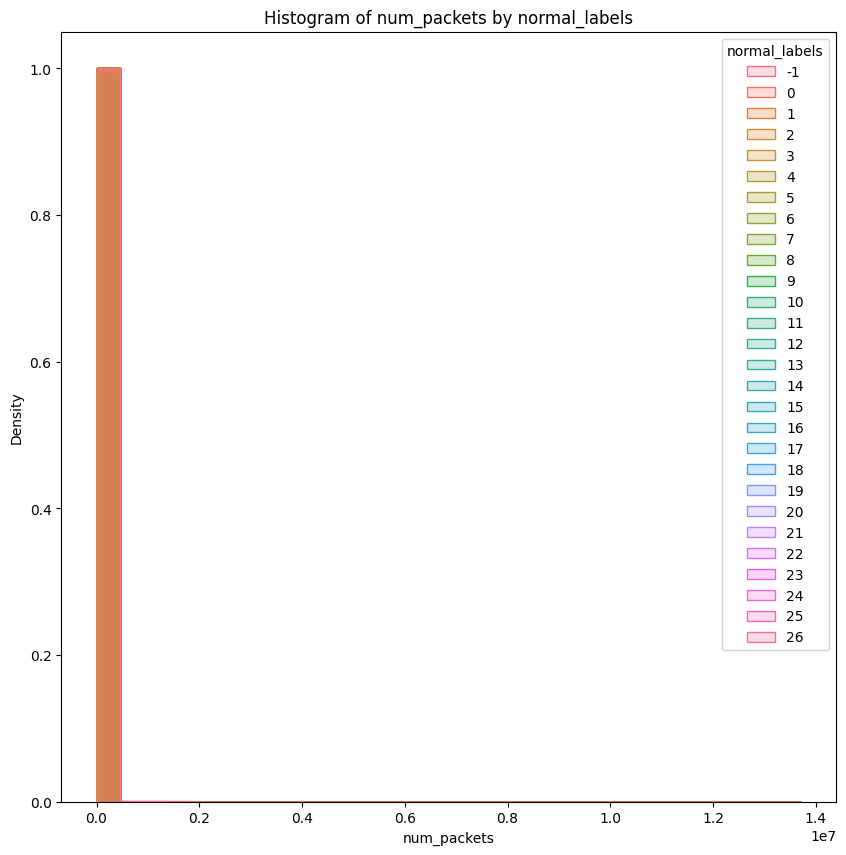

same_packet_size_flag


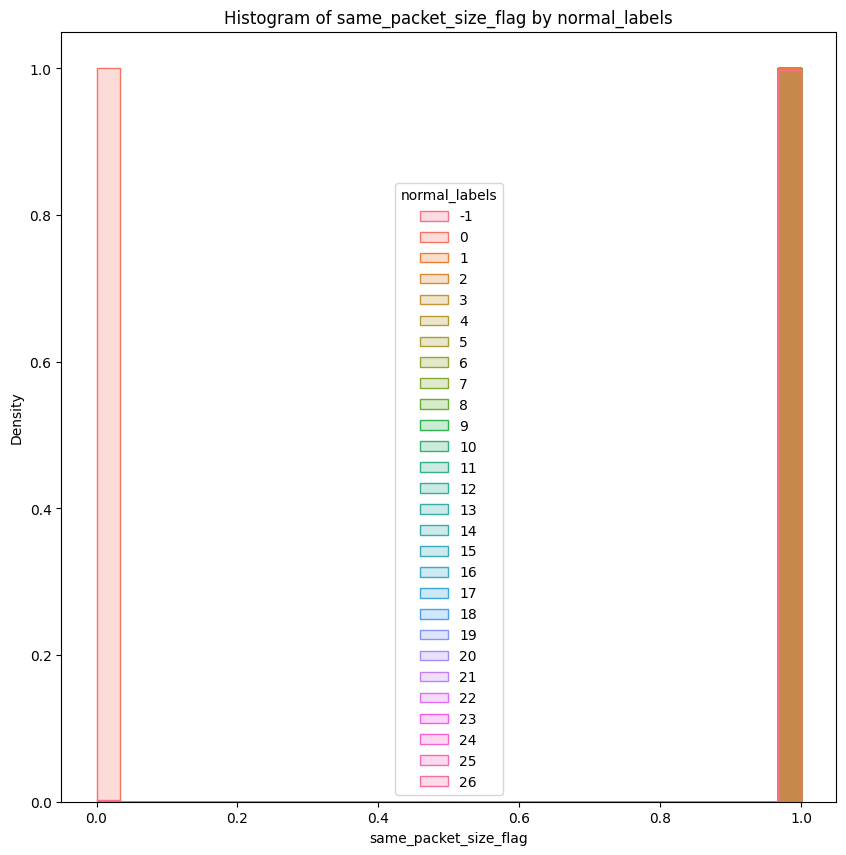

avg_packet_size


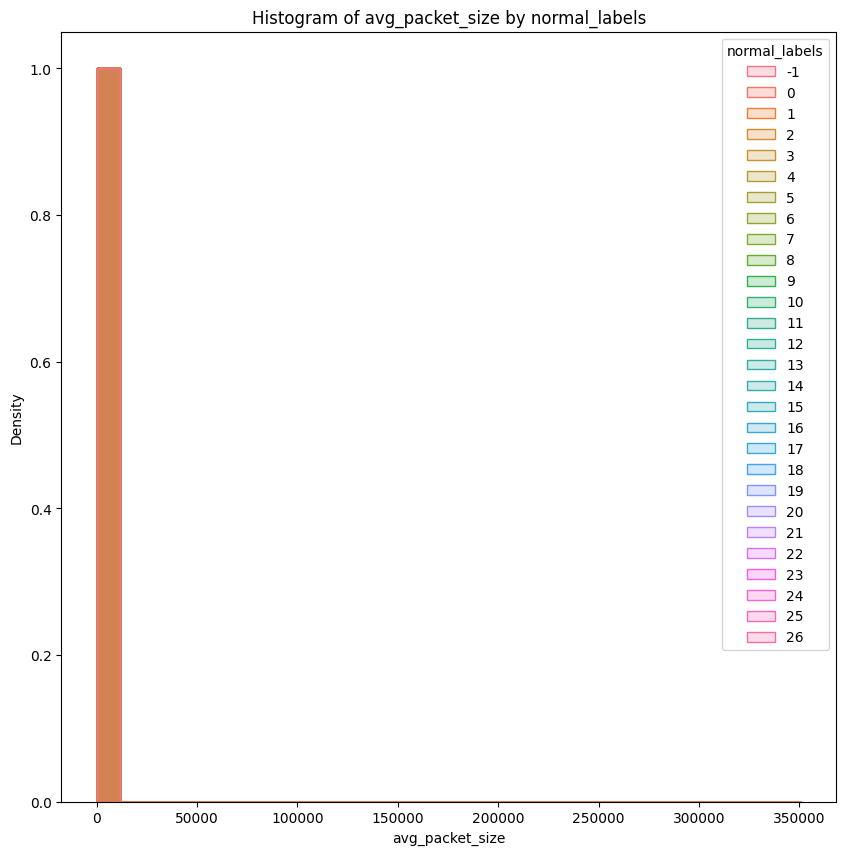

num_unique_Bs_scanned


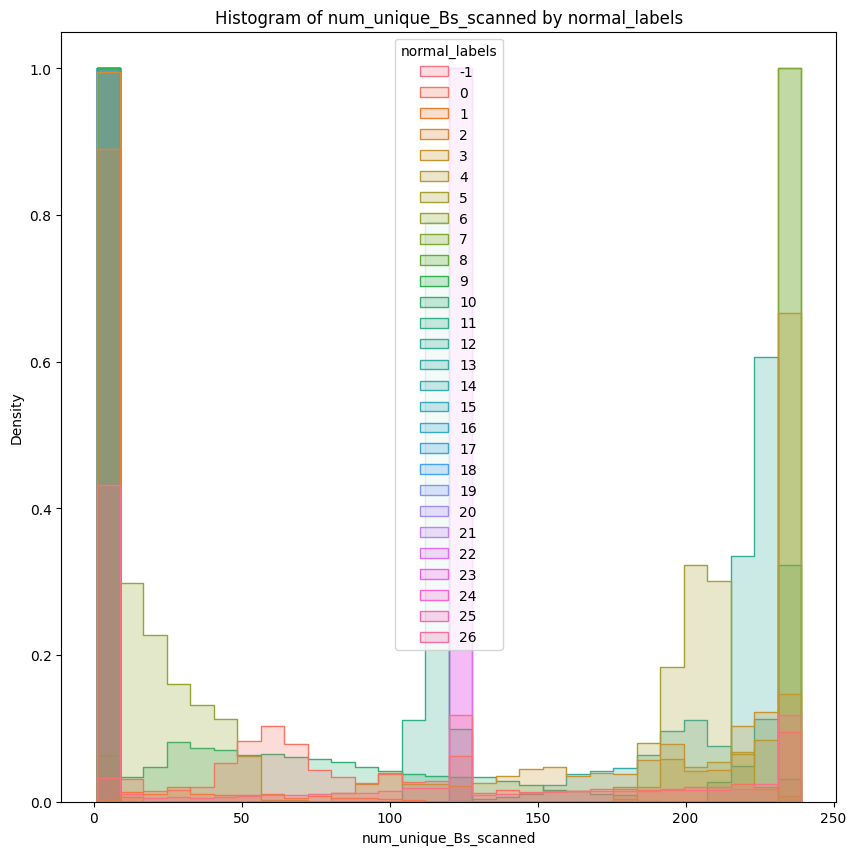

num_unique_Cs_scanned


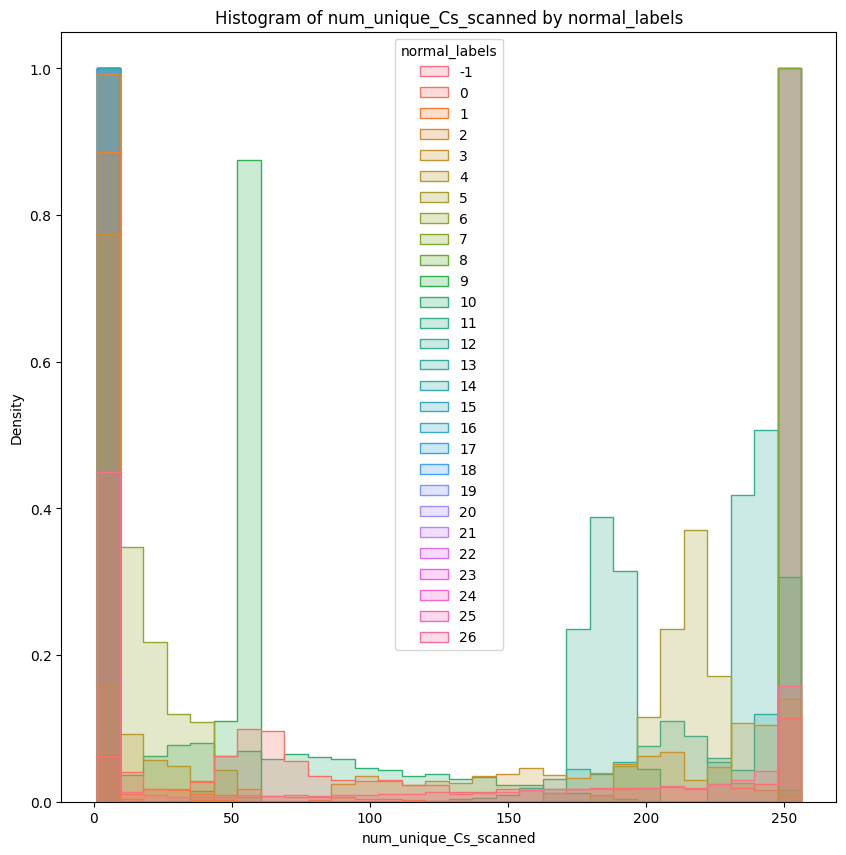

num_unique_Ds_scanned


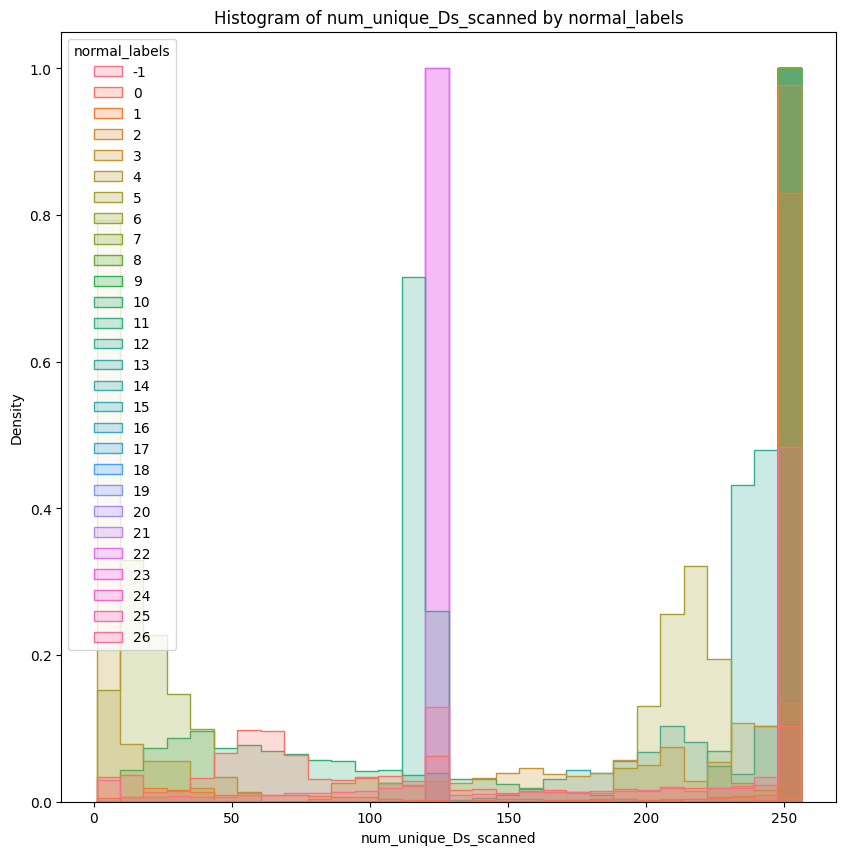

num_scanned_24_blocks


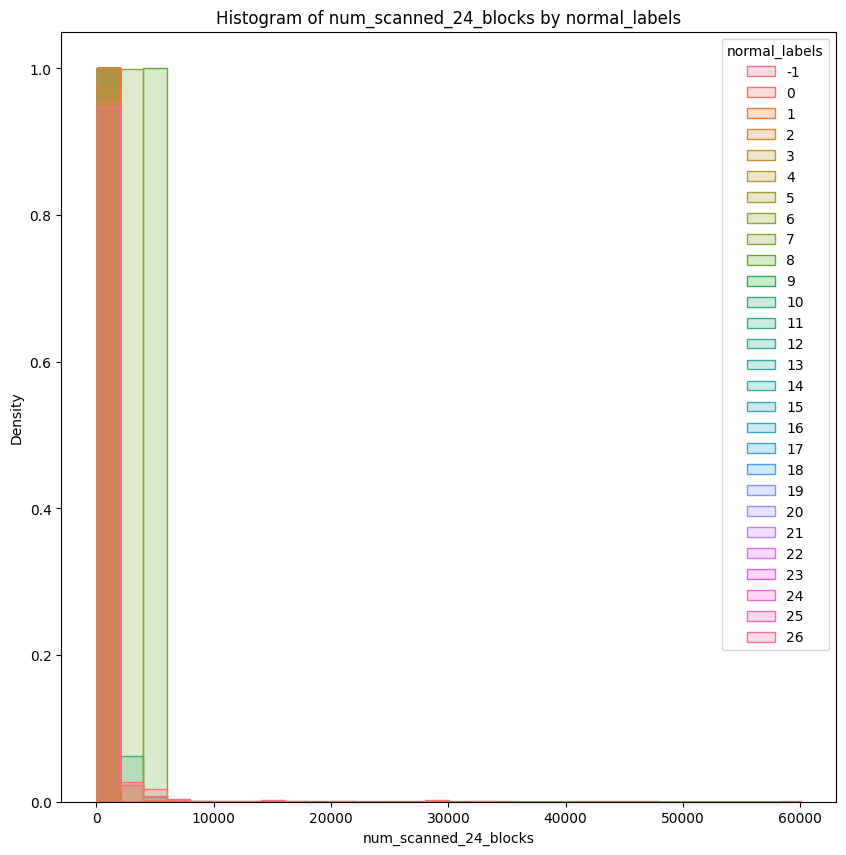

num_non_conficker_destinations


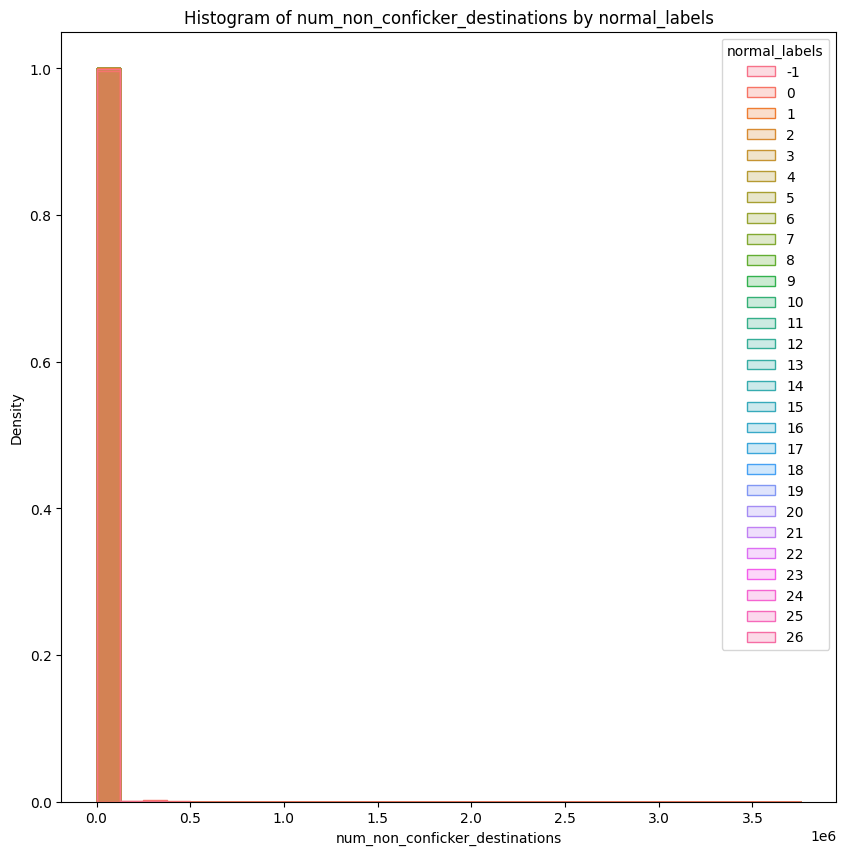

time_activity


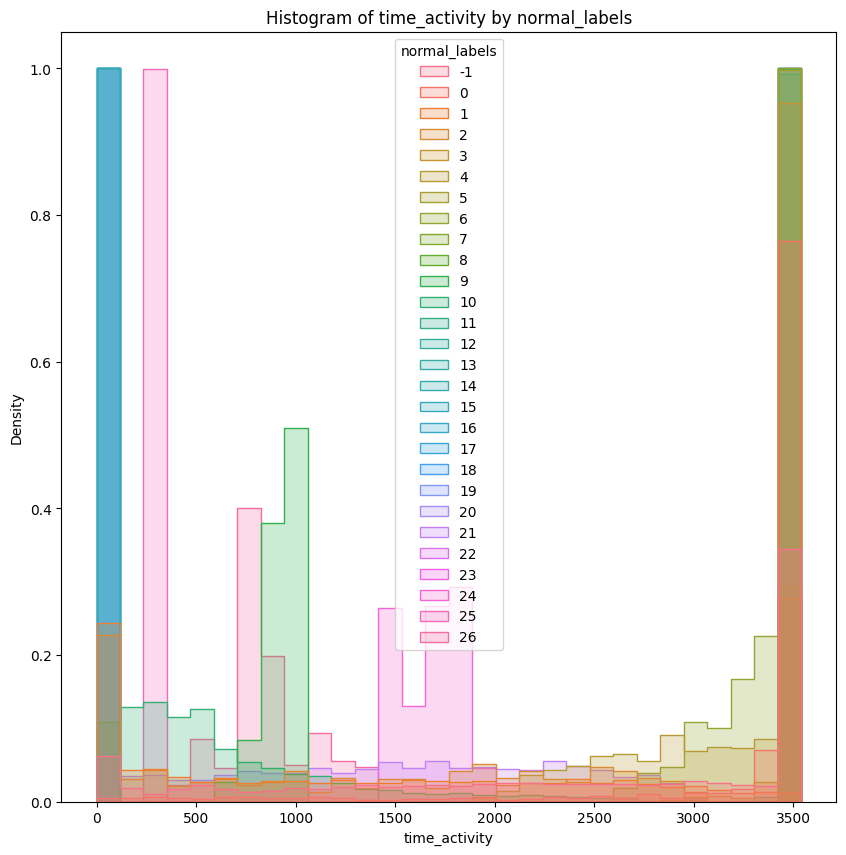

ip_scanned_rate


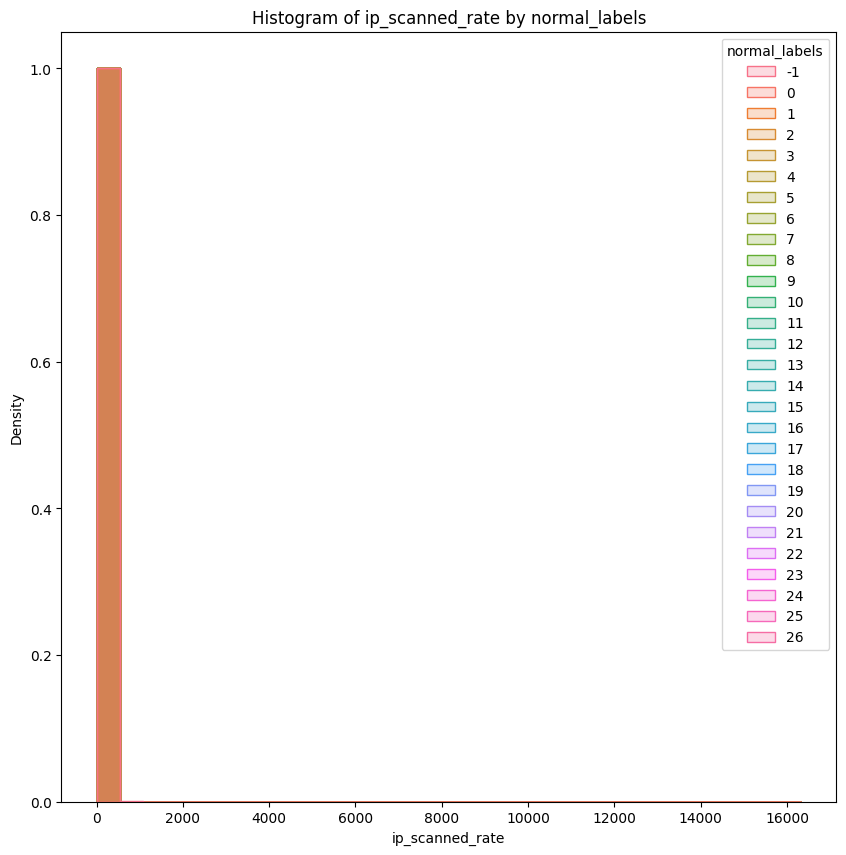

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df['normal_labels'] = df['normal_labels'].astype('category')
num_plots = len(numeric_columns)

for col in numeric_columns:
  print(col)
  plt.figure(figsize=(10, 10))
  sns.histplot(data=df, x=col, hue='normal_labels', element='step',
                stat='probability', common_norm=False, bins=30)
  plt.title(f"Histogram of {col} by normal_labels")
  plt.xlabel(col)
  plt.ylabel("Density")
  plt.savefig(VIZ_FOLDER / f"normal_{col}", dpi=100)
  plt.show()

plt.tight_layout()
plt.show()

# Graph Clusters

num_scanned_destination_ips


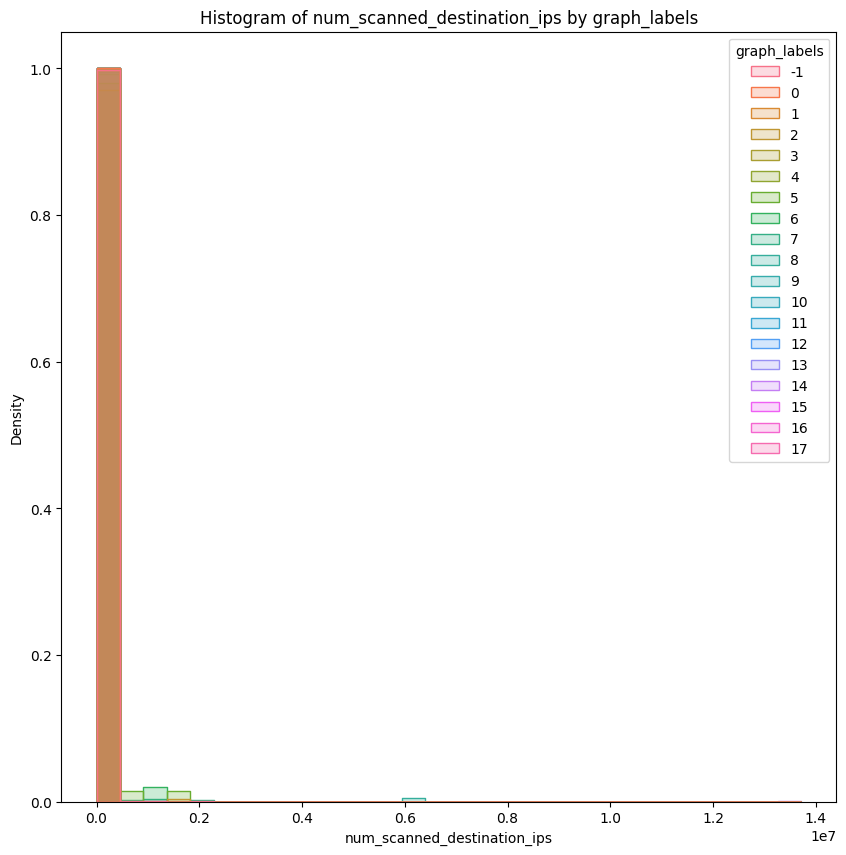

num_unique_flows


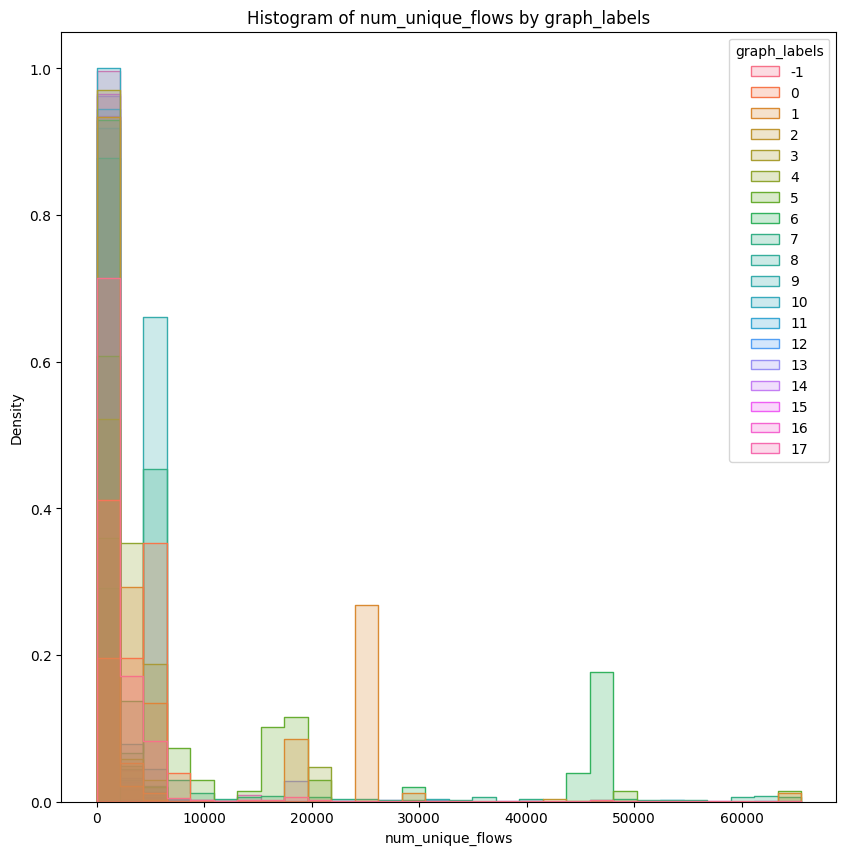

num_packets


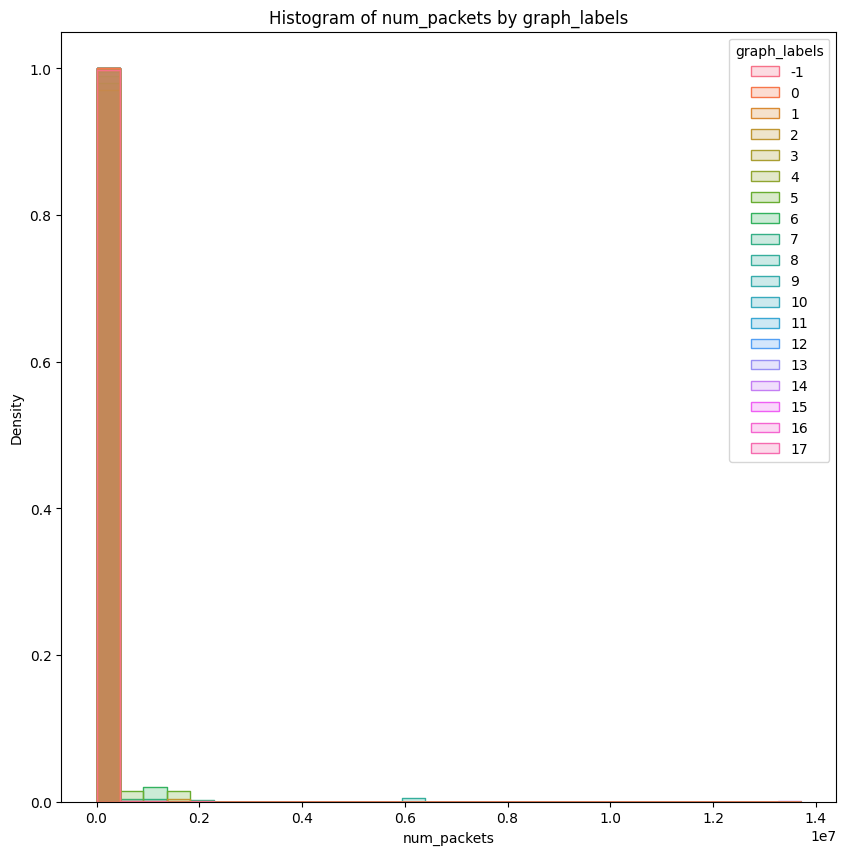

same_packet_size_flag


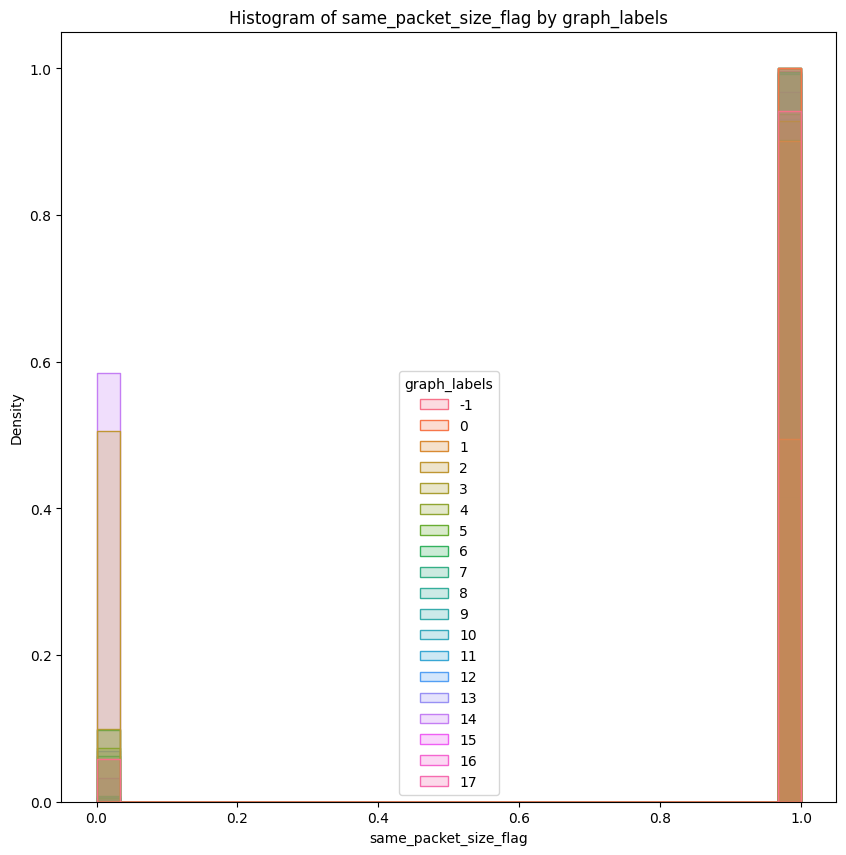

avg_packet_size


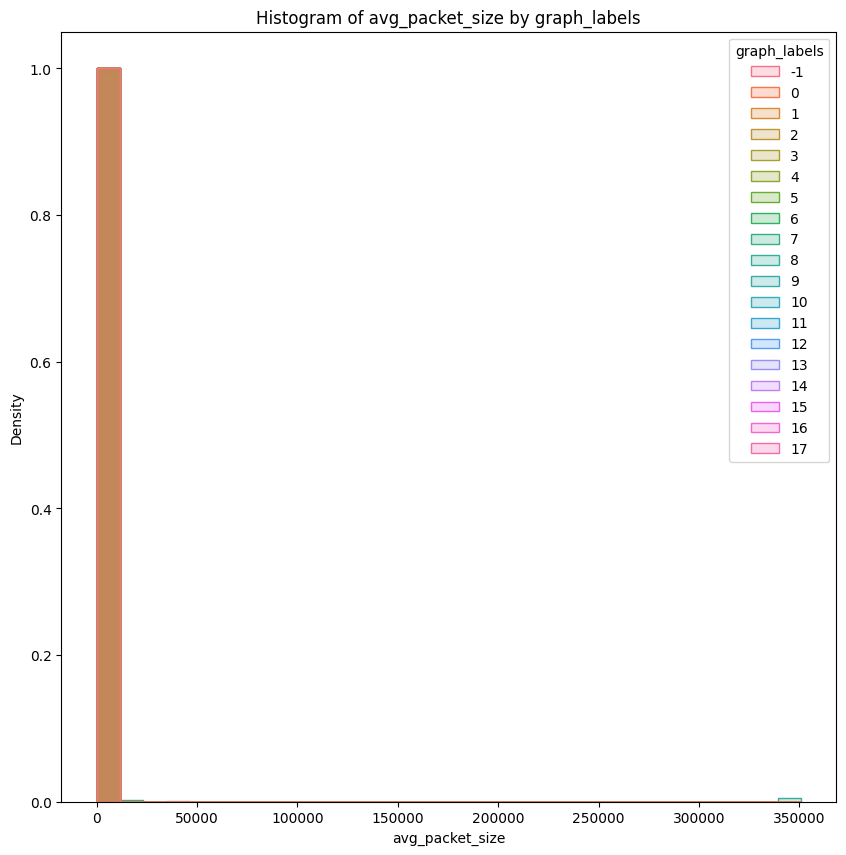

num_unique_Bs_scanned


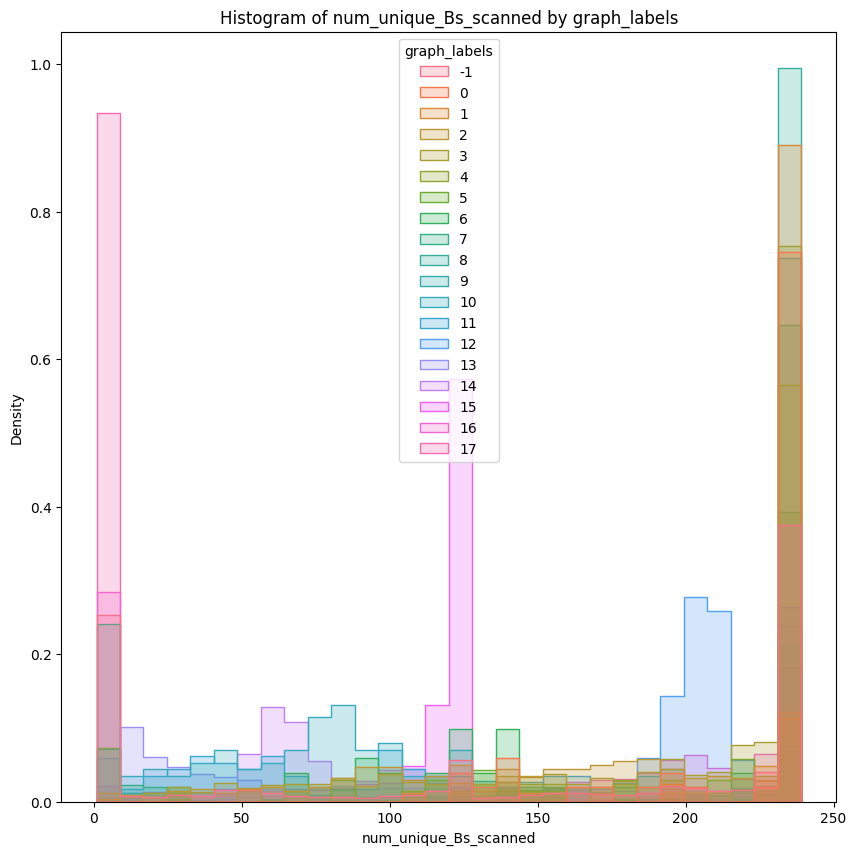

num_unique_Cs_scanned


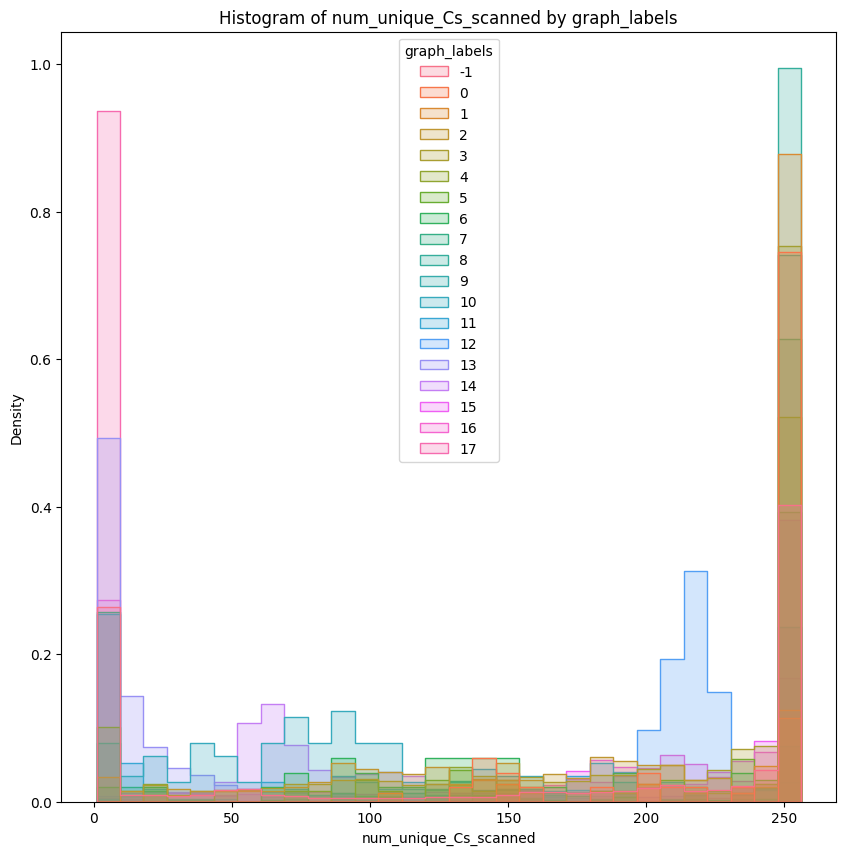

num_unique_Ds_scanned


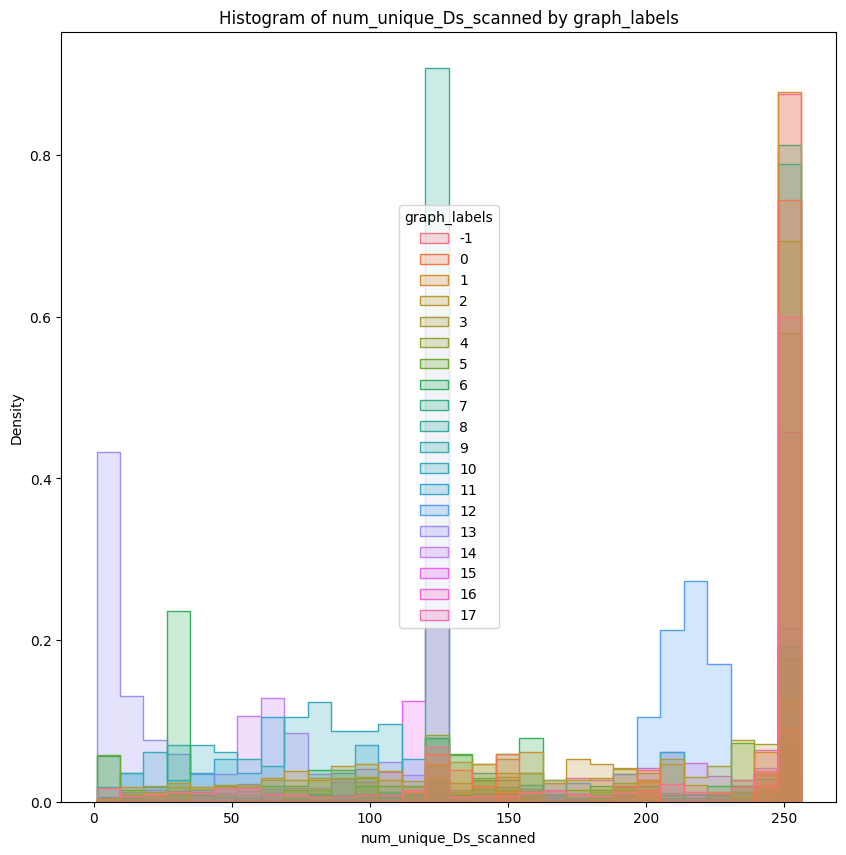

num_scanned_24_blocks


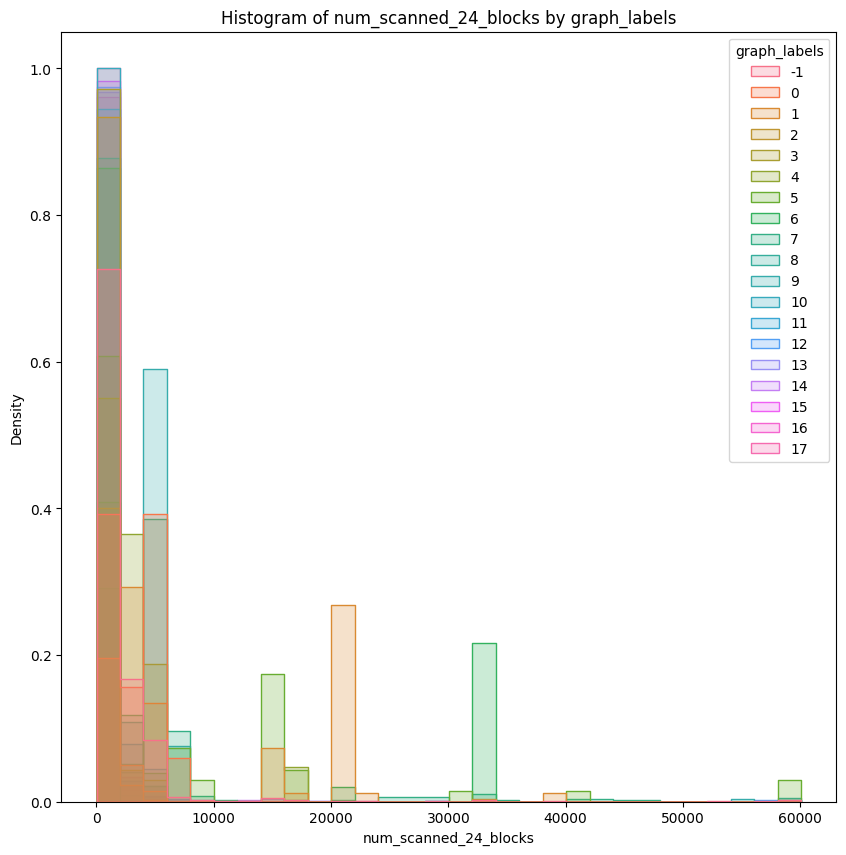

num_non_conficker_destinations


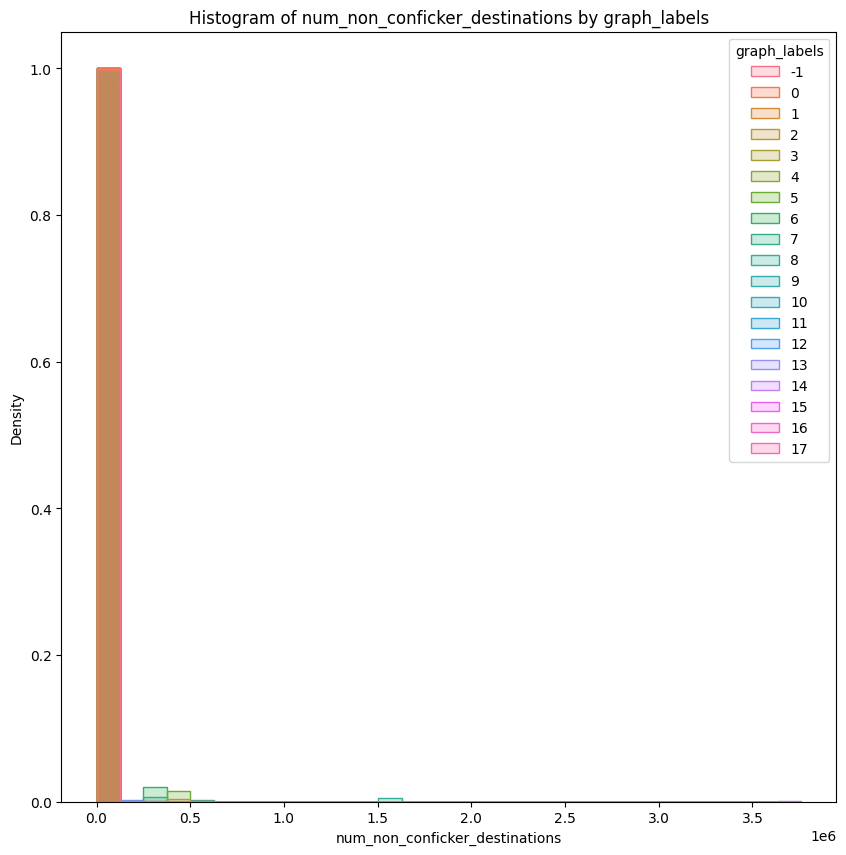

time_activity


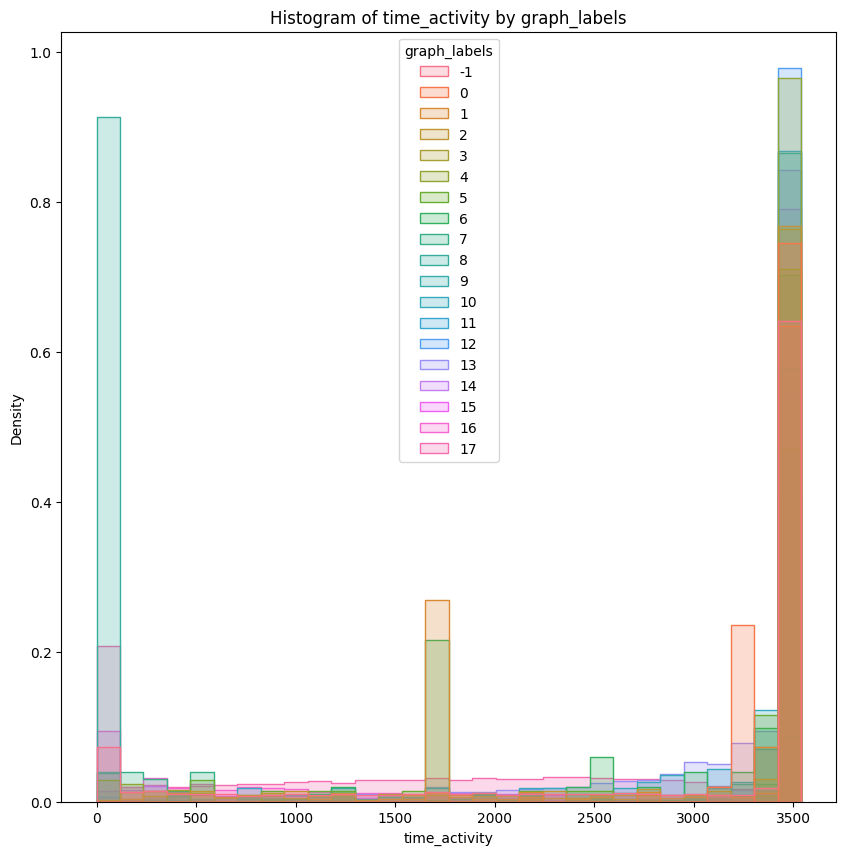

ip_scanned_rate


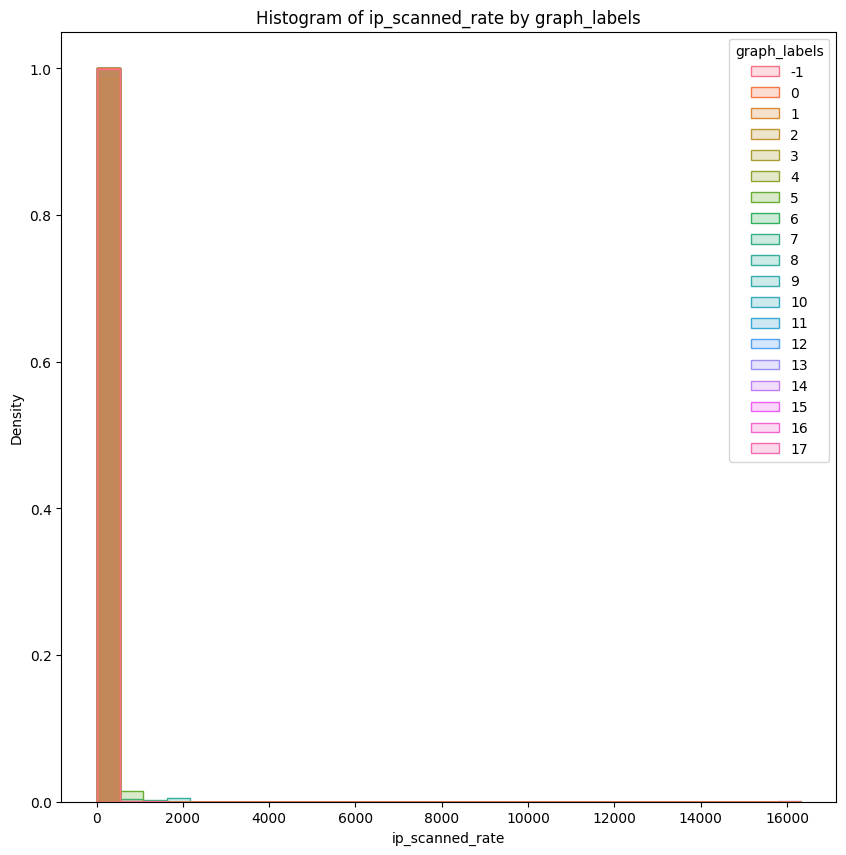

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df['graph_labels'] = df['graph_labels'].astype('category')
num_plots = len(numeric_columns)

for col in numeric_columns:
  print(col)
  plt.figure(figsize=(10, 10))
  sns.histplot(data=df, x=col, hue='graph_labels', element='step',
                stat='probability', common_norm=False, bins=30)
  plt.title(f"Histogram of {col} by graph_labels")
  plt.xlabel(col)
  plt.ylabel("Density")
  plt.savefig(VIZ_FOLDER / f"graph_{col}", dpi=100)
  plt.show()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_plots = len(numeric_columns)

for col in numeric_columns:
    for label in df['graph_labels'].unique():
      plt.figure(figsize=(8, 4), dpi=100)
      sns.histplot(data=df[df['graph_labels'] == label], x=col, element='step', kde=True,
                  stat='probability', common_norm=False)
      plt.title(f"Histogram of {col} by graph_labels_{label}")
      plt.xlabel(col)
      plt.ylabel("Density")
      plt.legend(title='graph_labels')
      plt.show()

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.